# Notebook 03 — Preprocessing & Augmentation Pipeline

**Objective:** Build a robust, reproducible preprocessing pipeline that transforms raw PlantVillage images into model-ready tensors, applies data augmentation to combat class imbalance, and produces strictly separated train / validation / test splits.

**Topics Covered:**
- ✅ Standardise image size to **224 × 224** pixels
- ✅ Normalise pixel arrays to `[0, 1]` float32
- ✅ Apply data augmentation (rotations, flips, zoom, contrast adjustments)
- ✅ Stratified **70 / 15 / 15** train / val / test split
- ✅ Persist processed split manifests and verify no leakage

**Input:** `data/metadata/inventory.csv` (from Step 1)  
**Output:** 
- `data/splits/` — `train.csv`, `val.csv`, `test.csv`
- `reports/04a_augmentation_visualization.png`
- `reports/04b_preprocessing_summary.png`

## Import Packages

In [14]:
import warnings
import shutil
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image, ImageEnhance
from tqdm import tqdm
import IPython

from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')

# ── Plot style ─────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 12,
    'axes.labelsize': 11,
})
sns.set_palette('viridis')

print('✅ Packages imported successfully')

✅ Packages imported successfully


## Define Paths & Global Constants

In [15]:
# ── Resolve project root ────────────────────────────────────────────────────────
_nb_path = Path(IPython.get_ipython().run_line_magic('pwd', '') if IPython.get_ipython() else '.').resolve()
PROJECT_ROOT = _nb_path.parent

DATA_DIR       = PROJECT_ROOT / 'data'
METADATA_DIR   = DATA_DIR / 'metadata'
SPLITS_DIR     = DATA_DIR / 'splits'
REPORTS_DIR    = PROJECT_ROOT / 'reports'

# ── Preprocessing constants ────────────────────────────────────────────────────
IMG_SIZE    = (224, 224)   # Target spatial resolution (H × W)
SEED        = 42           # Reproducibility seed

# Train / Val / Test ratios — must sum to 1.0
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15

FRAMEWORK = 'pytorch'  # Options: 'pytorch' or 'keras'

assert abs(TRAIN_RATIO + VAL_RATIO + TEST_RATIO - 1.0) < 1e-9, "Ratios must sum to 1"

print(f'✅ Paths configured')
print(f'   IMG_SIZE      : {IMG_SIZE}')
print(f'   Split ratios  : Train={TRAIN_RATIO:.0%}  Val={VAL_RATIO:.0%}  Test={TEST_RATIO:.0%}')

✅ Paths configured
   IMG_SIZE      : (224, 224)
   Split ratios  : Train=70%  Val=15%  Test=15%


## Load Inventory from Step 1

In [16]:
inventory_path = METADATA_DIR / 'inventory.csv'

if not inventory_path.exists():
    raise FileNotFoundError(
        f"❌ {inventory_path} not found.\n"
        "   Please run 01_image_acquisition.ipynb first."
    )
df = pd.read_csv(inventory_path)

print(f'✅ Inventory loaded: {len(df):,} images across {df["label"].nunique()} classes')
print(f'   Columns : {df.columns.tolist()}')

✅ Inventory loaded: 20,638 images across 15 classes
   Columns : ['path', 'filename', 'extension', 'label', 'crop', 'disease']


## Encode Labels

Create an integer `label_id` for each unique folder name (`label`). This mapping is persisted so model evaluation notebooks can decode predictions back to human-readable names.

In [17]:
# Build a sorted, deterministic label → integer mapping
unique_labels = sorted(df['label'].unique())
label_to_id   = {lbl: idx for idx, lbl in enumerate(unique_labels)}
id_to_label   = {idx: lbl for lbl, idx in label_to_id.items()}

df['label_id'] = df['label'].map(label_to_id)

# Save mapping for use by downstream notebooks
mapping_df = pd.DataFrame([
    {'label_id': idx, 'label': lbl}
    for lbl, idx in label_to_id.items()
])
mapping_path = METADATA_DIR / 'label_mapping.csv'
mapping_df.to_csv(mapping_path, index=False)

print(f'✅ Label encoding complete: {len(unique_labels)} classes')
print(f'   Saved: {mapping_path}')
print()
print("Sample mapping (first 10):")
print(mapping_df.head(10).to_string(index=False))

✅ Label encoding complete: 15 classes
   Saved: /home/tech-angel/PycharmProjects/agrolens-ai/data/metadata/label_mapping.csv

Sample mapping (first 10):
 label_id                         label
        0 Pepper__bell___Bacterial_spot
        1        Pepper__bell___healthy
        2         Potato___Early_blight
        3          Potato___Late_blight
        4              Potato___healthy
        5         Tomato_Bacterial_spot
        6           Tomato_Early_blight
        7            Tomato_Late_blight
        8              Tomato_Leaf_Mold
        9     Tomato_Septoria_leaf_spot


## Stratified Train / Validation / Test Split

A **stratified** split ensures that every class appears in all three sets at its natural proportion — critical given the class imbalance identified in Stage 2.

**Strategy:**  
1. First split into train (70%) and temp (30%) — stratified by `label`.  
2. Then split temp into val (50% of 30% = 15%) and test (50% of 30% = 15%) — stratified by `label`.

> **No data leakage guarantee:** Images are split by `path` — the same physical file will appear in exactly one of the three sets.

In [18]:
# ── Stage 1: train vs. temp ─────────────────────────────────────────────────────
df_train, df_temp = train_test_split(
    df,
    test_size=(VAL_RATIO + TEST_RATIO),
    stratify=df['label'],
    random_state=SEED
)

# ── Stage 2: val vs. test (equal halves of temp) ───────────────────────────────
df_val, df_test = train_test_split(
    df_temp,
    test_size=TEST_RATIO / (VAL_RATIO + TEST_RATIO),
    stratify=df_temp['label'],
    random_state=SEED
)

# Tag each split
df_train = df_train.copy(); df_train['split'] = 'train'
df_val   = df_val.copy();   df_val['split']   = 'val'
df_test  = df_test.copy();  df_test['split']  = 'test'

print("SPLIT SUMMARY")
print("="*60)
print(f"  Train : {len(df_train):6,} images  ({len(df_train)/len(df):.1%})")
print(f"  Val   : {len(df_val):6,} images  ({len(df_val)/len(df):.1%})")
print(f"  Test  : {len(df_test):6,} images  ({len(df_test)/len(df):.1%})")
print(f"  Total : {len(df_train)+len(df_val)+len(df_test):6,} images")

# ── Leakage check ──────────────────────────────────────────────────────────────
train_paths = set(df_train['path'])
val_paths   = set(df_val['path'])
test_paths  = set(df_test['path'])

train_val_overlap  = len(train_paths & val_paths)
train_test_overlap = len(train_paths & test_paths)
val_test_overlap   = len(val_paths   & test_paths)

print()
print("DATA LEAKAGE CHECK")
print("-"*40)
print(f"  Train ∩ Val  overlap : {train_val_overlap}")
print(f"  Train ∩ Test overlap : {train_test_overlap}")
print(f"  Val   ∩ Test overlap : {val_test_overlap}")

if train_val_overlap == 0 and train_test_overlap == 0 and val_test_overlap == 0:
    print("  ✅ No leakage detected — splits are strictly disjoint")
else:
    print("  ❌ LEAKAGE DETECTED — investigate before proceeding")

SPLIT SUMMARY
  Train : 14,446 images  (70.0%)
  Val   :  3,096 images  (15.0%)
  Test  :  3,096 images  (15.0%)
  Total : 20,638 images

DATA LEAKAGE CHECK
----------------------------------------
  Train ∩ Val  overlap : 0
  Train ∩ Test overlap : 0
  Val   ∩ Test overlap : 0
  ✅ No leakage detected — splits are strictly disjoint


## Save Split Manifests

In [19]:
for split_df, name in [(df_train, 'train'), (df_val, 'val'), (df_test, 'test')]:
    out_path = SPLITS_DIR / f'{name}.csv'
    split_df.to_csv(out_path, index=False)
    print(f'✅ Saved {name:5} split → {out_path}  ({len(split_df):,} rows)')

✅ Saved train split → /home/tech-angel/PycharmProjects/agrolens-ai/data/splits/train.csv  (14,446 rows)
✅ Saved val   split → /home/tech-angel/PycharmProjects/agrolens-ai/data/splits/val.csv  (3,096 rows)
✅ Saved test  split → /home/tech-angel/PycharmProjects/agrolens-ai/data/splits/test.csv  (3,096 rows)


## Verify Stratification

Check that the class proportions are consistent across all three splits. Any class whose share deviates by more than 2 pp from the training set warrants investigation.

In [20]:
def class_proportions(split_df: pd.DataFrame, split_name: str) -> pd.Series:
    """Return per-class proportion Series for a given split."""
    counts = split_df['label'].value_counts()
    return (counts / counts.sum()).rename(split_name)


props = pd.concat([
    class_proportions(df_train, 'train'),
    class_proportions(df_val,   'val'),
    class_proportions(df_test,  'test'),
], axis=1).fillna(0)

# Maximum deviation from train proportion
props['max_dev'] = props[['val', 'test']].subtract(props['train'], axis=0).abs().max(axis=1)
flagged = props[props['max_dev'] > 0.02]

print("STRATIFICATION VERIFICATION")
print("="*60)
print(f"  Classes with >2pp deviation from train proportion: {len(flagged)}")

if flagged.empty:
    print("  ✅ All classes are well-stratified across splits")
else:
    print("  ⚠️  Classes with large deviation:")
    print(flagged[['train', 'val', 'test', 'max_dev']].to_string())

print()
print("Class proportions (first 8 classes):")
print(props[['train', 'val', 'test']].head(8).round(4).to_string())

STRATIFICATION VERIFICATION
  Classes with >2pp deviation from train proportion: 0
  ✅ All classes are well-stratified across splits

Class proportions (first 8 classes):
                                              train     val    test
label                                                              
Tomato__Tomato_YellowLeaf__Curl_Virus        0.1554  0.1554  0.1557
Tomato_Bacterial_spot                        0.1031  0.1030  0.1030
Tomato_Late_blight                           0.0925  0.0924  0.0927
Tomato_Septoria_leaf_spot                    0.0858  0.0856  0.0859
Tomato_Spider_mites_Two_spotted_spider_mite  0.0812  0.0811  0.0814
Tomato_healthy                               0.0771  0.0772  0.0769
Pepper__bell___healthy                       0.0716  0.0717  0.0714
Tomato__Target_Spot                          0.0680  0.0682  0.0678


## Core Preprocessing Function

The `preprocess_image()` function implements the standardised pipeline applied to **every** image before it enters the model:

| Step | Operation | Rationale |
|------|-----------|----------|
| 1 | **Load** via OpenCV | Industry-standard, handles most formats |
| 2 | **BGR → RGB** | OpenCV loads BGR; all downstream code uses RGB |
| 3 | **Resize** to 224 × 224 | Fixed input size required by CNN / transfer-learning backbones |
| 4 | **Normalise** pixel values to `[0, 1]` | Accelerates gradient descent; standard for pretrained ImageNet models |
| 5 | **Cast** to `float32` | Memory-efficient; compatible with TensorFlow / PyTorch tensors |

In [21]:
"""
Load, resize, and normalise a single image.

Args:
    path        : Absolute or relative path to the source image file.
    target_size : (height, width) tuple for resizing.

Returns:
    float32 NumPy array of shape (H, W, 3) with values in [0, 1],
    or None if the image could not be loaded.
"""
def preprocess_image(path: str,
                     target_size: tuple = IMG_SIZE
                     ) -> np.ndarray | None:
    try:
        p = Path(path)
        if not p.exists():
            return None

        # Step 1 & 2: Load and convert colour space
        img_bgr = cv2.imread(str(p))
        if img_bgr is None:
            return None
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        # Step 3: Resize using LANCZOS for high-quality downsampling
        img_resized = cv2.resize(img_rgb, target_size, interpolation=cv2.INTER_LANCZOS4)

        # Step 4 & 5: Normalise and cast
        img_normalised = img_resized.astype(np.float32) / 255.0

        return img_normalised

    except Exception as e:
        print(f'⚠️  Error preprocessing {path}: {e}')
        return None


# ── Sanity check on one image ──────────────────────────────────────────────────
sample_path = df.iloc[0]['path']
sample_img = preprocess_image(sample_path)

if sample_img is not None:
    print(f'✅ Preprocessing verified on sample image')
    print(f'   Source path  : {sample_path}')
    print(f'   Output shape : {sample_img.shape}   (H × W × C)')
    print(f'   dtype        : {sample_img.dtype}')
    print(f'   Pixel range  : [{sample_img.min():.4f}, {sample_img.max():.4f}]')
else:
    print('⚠️  Sample image could not be loaded — verify data paths in inventory.csv')

✅ Preprocessing verified on sample image
   Source path  : /home/tech-angel/PycharmProjects/agrolens-ai/data/raw/plant_village/Pepper__bell___Bacterial_spot/2700e5b5-295c-4378-b829-0e5989864380___NREC_B.Spot 9091.JPG
   Output shape : (224, 224, 3)   (H × W × C)
   dtype        : float32
   Pixel range  : [0.0000, 1.0000]


## Data Augmentation Functions

Augmentation is applied **only to training images** at load time (online augmentation). This artificially expands the effective dataset size, reduces overfitting, and helps the model generalise to real field conditions such as variable lighting and camera angles.

### Augmentation Transforms Applied

| Transform | Range / Options | Agricultural Rationale |
|-----------|----------------|------------------------|
| Horizontal flip | 50% probability | Leaf orientation is arbitrary in field photos |
| Vertical flip | 50% probability | Overhead/angled shots produce any orientation |
| Rotation | ±30° | Farmers photograph leaves at random angles |
| Zoom / crop | 80–100% of image | Variable camera distance in field conditions |
| Brightness | ±30% | Shade, cloud cover, and direct sunlight vary throughout the day |
| Contrast | ±20% | Lens quality and dust affect image clarity |

In [22]:
"""
Apply a randomised augmentation pipeline to a preprocessed image array.

Args:
    img  : float32 NumPy array of shape (H, W, 3) with values in [0, 1].
    seed : Optional integer seed for reproducible augmentation (testing).

Returns:
    Augmented float32 NumPy array of the same shape.

Note:
    Each transform is applied independently with its own probability.
    All operations preserve the [0, 1] value range via np.clip.
"""

def augment_image(img: np.ndarray,
                  seed: int | None = None
                  ) -> np.ndarray:
    
    rng = np.random.default_rng(seed)
    h, w = img.shape[:2]

    # Work on a copy to avoid mutating the original
    out = img.copy()

    # ── 1. Horizontal flip ─────────────────────────────────────────────────────
    if rng.random() < 0.5:
        out = np.fliplr(out)

    # ── 2. Vertical flip ───────────────────────────────────────────────────────
    if rng.random() < 0.5:
        out = np.flipud(out)

    # ── 3. Random rotation (±30°) ──────────────────────────────────────────────
    if rng.random() < 0.7:
        angle   = rng.uniform(-30, 30)
        center  = (w // 2, h // 2)
        rot_mat = cv2.getRotationMatrix2D(center, angle, scale=1.0)
        out = cv2.warpAffine(
            out, rot_mat, (w, h),
            flags=cv2.INTER_LANCZOS4,
            borderMode=cv2.BORDER_REFLECT_101
        )

    # ── 4. Random zoom / central crop ─────────────────────────────────────────
    if rng.random() < 0.5:
        zoom_factor = rng.uniform(0.80, 1.00)   # crop 80–100% of the image
        crop_h = int(h * zoom_factor)
        crop_w = int(w * zoom_factor)
        top  = (h - crop_h) // 2
        left = (w - crop_w) // 2
        cropped = out[top:top + crop_h, left:left + crop_w]
        out = cv2.resize(cropped, (w, h), interpolation=cv2.INTER_LANCZOS4)

    # ── 5. Brightness jitter (±30%) ────────────────────────────────────────────
    if rng.random() < 0.6:
        factor = rng.uniform(0.70, 1.30)
        out = np.clip(out * factor, 0.0, 1.0)

    # ── 6. Contrast jitter (±20%) ──────────────────────────────────────────────
    if rng.random() < 0.6:
        mean   = out.mean()
        factor = rng.uniform(0.80, 1.20)
        out    = np.clip((out - mean) * factor + mean, 0.0, 1.0)

    return out.astype(np.float32)

print('✅ augment_image() defined')
print('   Transforms: horizontal flip | vertical flip | rotation ±30° | zoom | brightness | contrast')

✅ augment_image() defined
   Transforms: horizontal flip | vertical flip | rotation ±30° | zoom | brightness | contrast


## Visualise Augmentation Effect

Display one original image alongside eight independently augmented versions to qualitatively confirm the pipeline is producing realistic variations.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.07977535..0.89126647].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.04227854..0.89501977].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.029835438..0.8799635].


✅ Saved: /home/tech-angel/PycharmProjects/agrolens-ai/reports/04a_augmentation_visualization.png


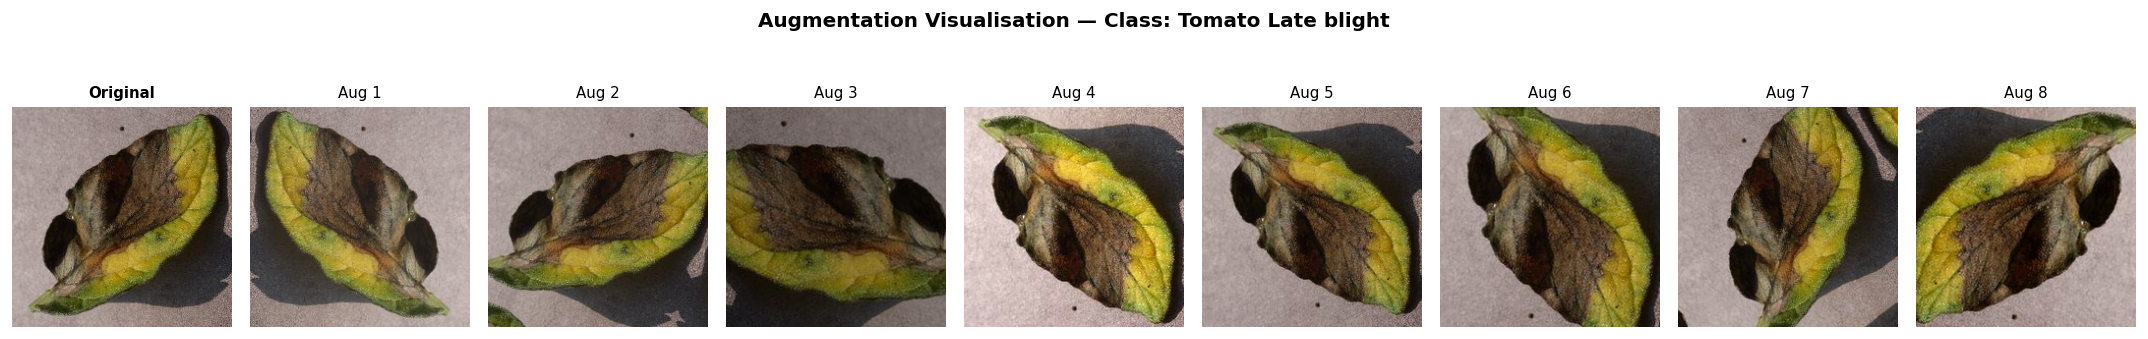

In [23]:
# Pick one sample training image to demonstrate augmentation
demo_row   = df_train.sample(1, random_state=SEED).iloc[0]
demo_img   = preprocess_image(demo_row['path'])

if demo_img is not None:
    n_augmented = 8
    fig, axes = plt.subplots(1, n_augmented + 1, figsize=(18, 3))

    # Original
    axes[0].imshow(demo_img)
    axes[0].set_title('Original', fontsize=9, fontweight='bold')
    axes[0].axis('off')

    # Augmented variants
    for i in range(n_augmented):
        aug = augment_image(demo_img, seed=None)   # random each time
        axes[i + 1].imshow(aug)
        axes[i + 1].set_title(f'Aug {i+1}', fontsize=9)
        axes[i + 1].axis('off')

    label_display = demo_row['label'].replace('_', ' ')
    fig.suptitle(
        f'Augmentation Visualisation — Class: {label_display}',
        fontsize=12, fontweight='bold', y=1.02
    )

    plt.tight_layout()
    aug_plot_path = REPORTS_DIR / '04a_augmentation_visualization.png'
    plt.savefig(aug_plot_path, dpi=200, bbox_inches='tight')
    print(f'✅ Saved: {aug_plot_path}')
    plt.show()
else:
    print('⚠️  Could not load demo image — verify data paths')

## TensorFlow / Keras Dataset Builder (Online Augmentation)

Rather than saving augmented images to disk (which would inflate storage 8×), the pipeline builds a **`tf.data.Dataset`** generator that applies augmentation on-the-fly during training. This approach:
- Keeps disk usage proportional to the original dataset size
- Ensures every epoch sees different augmented versions
- Supports parallel loading via `num_parallel_calls=AUTOTUNE`

> **Framework choice:** The cell below targets TensorFlow/Keras. If you are using PyTorch, a `Dataset` / `DataLoader` equivalent is provided in the next cell (commented out).

In [24]:
# ─────────────────────────────────────────────────────────────────────────────
#  TensorFlow / Keras  —  tf.data pipeline
# ─────────────────────────────────────────────────────────────────────────────
if FRAMEWORK == 'keras':
    print("✅ Running Keras Pipeline")
    try:
        import tensorflow as tf
        from tensorflow import keras
        print(f'✅ TensorFlow {tf.__version__} detected')

        AUTOTUNE    = tf.data.AUTOTUNE
        BATCH_SIZE  = 32
        N_CLASSES   = df['label'].nunique()

        # ── Keras augmentation layer (GPU-accelerated when available) ──────────────
        keras_augmentation = keras.Sequential([
            keras.layers.RandomFlip('horizontal_and_vertical'),
            keras.layers.RandomRotation(0.1),              # ±10% of 2π ≈ ±36°
            keras.layers.RandomZoom((-0.2, 0.0)),          # zoom in up to 20%
            keras.layers.RandomBrightness(0.3),
            keras.layers.RandomContrast(0.2),
        ], name='augmentation_pipeline')

        # ── Low-level load helper ──────────────────────────────────────────────────
        def load_and_preprocess_tf(path: str,
                                    label: int
                                    ) -> tuple[tf.Tensor, tf.Tensor]:
            """Read, decode, resize, and normalise one image."""
            raw   = tf.io.read_file(path)
            image = tf.image.decode_image(raw, channels=3, expand_animations=False)
            image = tf.image.resize(image, IMG_SIZE, method='lanczos3')
            image = tf.cast(image, tf.float32) / 255.0
            return image, label

        def build_tf_dataset(split_df: pd.DataFrame,
                            apply_augmentation: bool = False,
                            batch_size: int = BATCH_SIZE,
                            shuffle: bool = True
                            ) -> tf.data.Dataset:
            """
            Build a tf.data.Dataset from a split manifest DataFrame.

            Args:
                split_df           : DataFrame with 'path' and 'label_id' columns.
                apply_augmentation : If True, applies Keras augmentation (training only).
                batch_size         : Number of images per batch.
                shuffle            : Whether to shuffle the dataset (disable for val/test).

            Returns:
                A prefetched, batched tf.data.Dataset.
            """
            paths  = split_df['path'].values
            labels = split_df['label_id'].values

            dataset = tf.data.Dataset.from_tensor_slices((paths, labels))

            if shuffle:
                dataset = dataset.shuffle(
                    buffer_size=len(split_df),
                    seed=SEED,
                    reshuffle_each_iteration=True
                )

            # Load and preprocess in parallel
            dataset = dataset.map(
                load_and_preprocess_tf,
                num_parallel_calls=AUTOTUNE
            )

            # Apply augmentation to training set only
            if apply_augmentation:
                dataset = dataset.map(
                    lambda x, y: (keras_augmentation(x, training=True), y),
                    num_parallel_calls=AUTOTUNE
                )

            dataset = dataset.batch(batch_size).prefetch(AUTOTUNE)
            return dataset

        # ── Build the three datasets ───────────────────────────────────────────────
        train_ds = build_tf_dataset(df_train, apply_augmentation=True,  shuffle=True)
        val_ds   = build_tf_dataset(df_val,   apply_augmentation=False, shuffle=False)
        test_ds  = build_tf_dataset(df_test,  apply_augmentation=False, shuffle=False)

        print()
        print('✅ tf.data pipelines built successfully')
        print(f'   Train  — {len(df_train):,} images, {len(train_ds)} batches (aug=ON,  shuffle=ON)')
        print(f'   Val    — {len(df_val):,} images, {len(val_ds)} batches  (aug=OFF, shuffle=OFF)')
        print(f'   Test   — {len(df_test):,} images, {len(test_ds)} batches  (aug=OFF, shuffle=OFF)')

        # ── Verify a batch loads correctly ────────────────────────────────────────
        for batch_images, batch_labels in train_ds.take(1):
            print()
            print('Batch verification:')
            print(f'  Images shape : {batch_images.shape}  (batch × H × W × C)')
            print(f'  Labels shape : {batch_labels.shape}')
            print(f'  Pixel range  : [{float(tf.reduce_min(batch_images)):.4f}, {float(tf.reduce_max(batch_images)):.4f}]')

        TF_AVAILABLE = True

    except ImportError:
        print('ℹ️  TensorFlow not installed — skipping tf.data pipeline')
        print('   Install with: pip install tensorflow')
        TF_AVAILABLE = False

## PyTorch Dataset & DataLoader (Alternative)

If PyTorch is your preferred framework, uncomment and run the cell below. The `torchvision.transforms` pipeline mirrors the TensorFlow augmentation strategy.

In [25]:
# ─────────────────────────────────────────────────────────────────────────────
#  PyTorch  —  Dataset / DataLoader pipeline  (uncomment to use)
# ─────────────────────────────────────────────────────────────────────────────
if FRAMEWORK == 'pytorch':
    print("✅ Running PyTorch Pipeline")
    import torch
    from torch.utils.data import Dataset, DataLoader
    from torchvision import transforms

    # ── Augmentation transforms (training) ───────────────────────────────────────
    train_transform = transforms.Compose([
        transforms.Resize(IMG_SIZE),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.RandomRotation(degrees=30),
        transforms.RandomResizedCrop(size=IMG_SIZE, scale=(0.80, 1.00)),
        transforms.ColorJitter(brightness=0.3, contrast=0.2),
        transforms.ToTensor(),              # → float32 in [0, 1]
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],    # ImageNet statistics (for transfer learning)
            std=[0.229, 0.224, 0.225]
        ),
    ])

    # ── Inference transforms (val / test) ─────────────────────────────────────────
    eval_transform = transforms.Compose([
        transforms.Resize(IMG_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        ),
    ])


    class PlantVillageDataset(Dataset):
        def __init__(self, split_df: pd.DataFrame, transform=None):
            self.df        = split_df.reset_index(drop=True)
            self.transform = transform

        def __len__(self) -> int:
            return len(self.df)

        def __getitem__(self, idx: int):
            row = self.df.iloc[idx]
            img = Image.open(row['path']).convert('RGB')
            if self.transform:
                img = self.transform(img)
            label = torch.tensor(row['label_id'], dtype=torch.long)
            return img, label


    train_dataset = PlantVillageDataset(df_train, transform=train_transform)
    val_dataset   = PlantVillageDataset(df_val,   transform=eval_transform)
    test_dataset  = PlantVillageDataset(df_test,  transform=eval_transform)

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=4, pin_memory=True)
    val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=4, pin_memory=True)
    test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

    print(f'✅ PyTorch DataLoaders ready')
    print(f'   Train : {len(train_dataset):,} images | {len(train_loader)} batches')
    print(f'   Val   : {len(val_dataset):,} images | {len(val_loader)} batches')
    print(f'   Test  : {len(test_dataset):,} images | {len(test_loader)} batches')

✅ Running PyTorch Pipeline
✅ PyTorch DataLoaders ready
   Train : 14,446 images | 452 batches
   Val   : 3,096 images | 97 batches
   Test  : 3,096 images | 97 batches


## Preprocessing Pipeline Summary Report

Generate a 4-panel summary figure that documents the final split composition for the project report.

✅ Saved: /home/tech-angel/PycharmProjects/agrolens-ai/reports/04b_preprocessing_summary.png


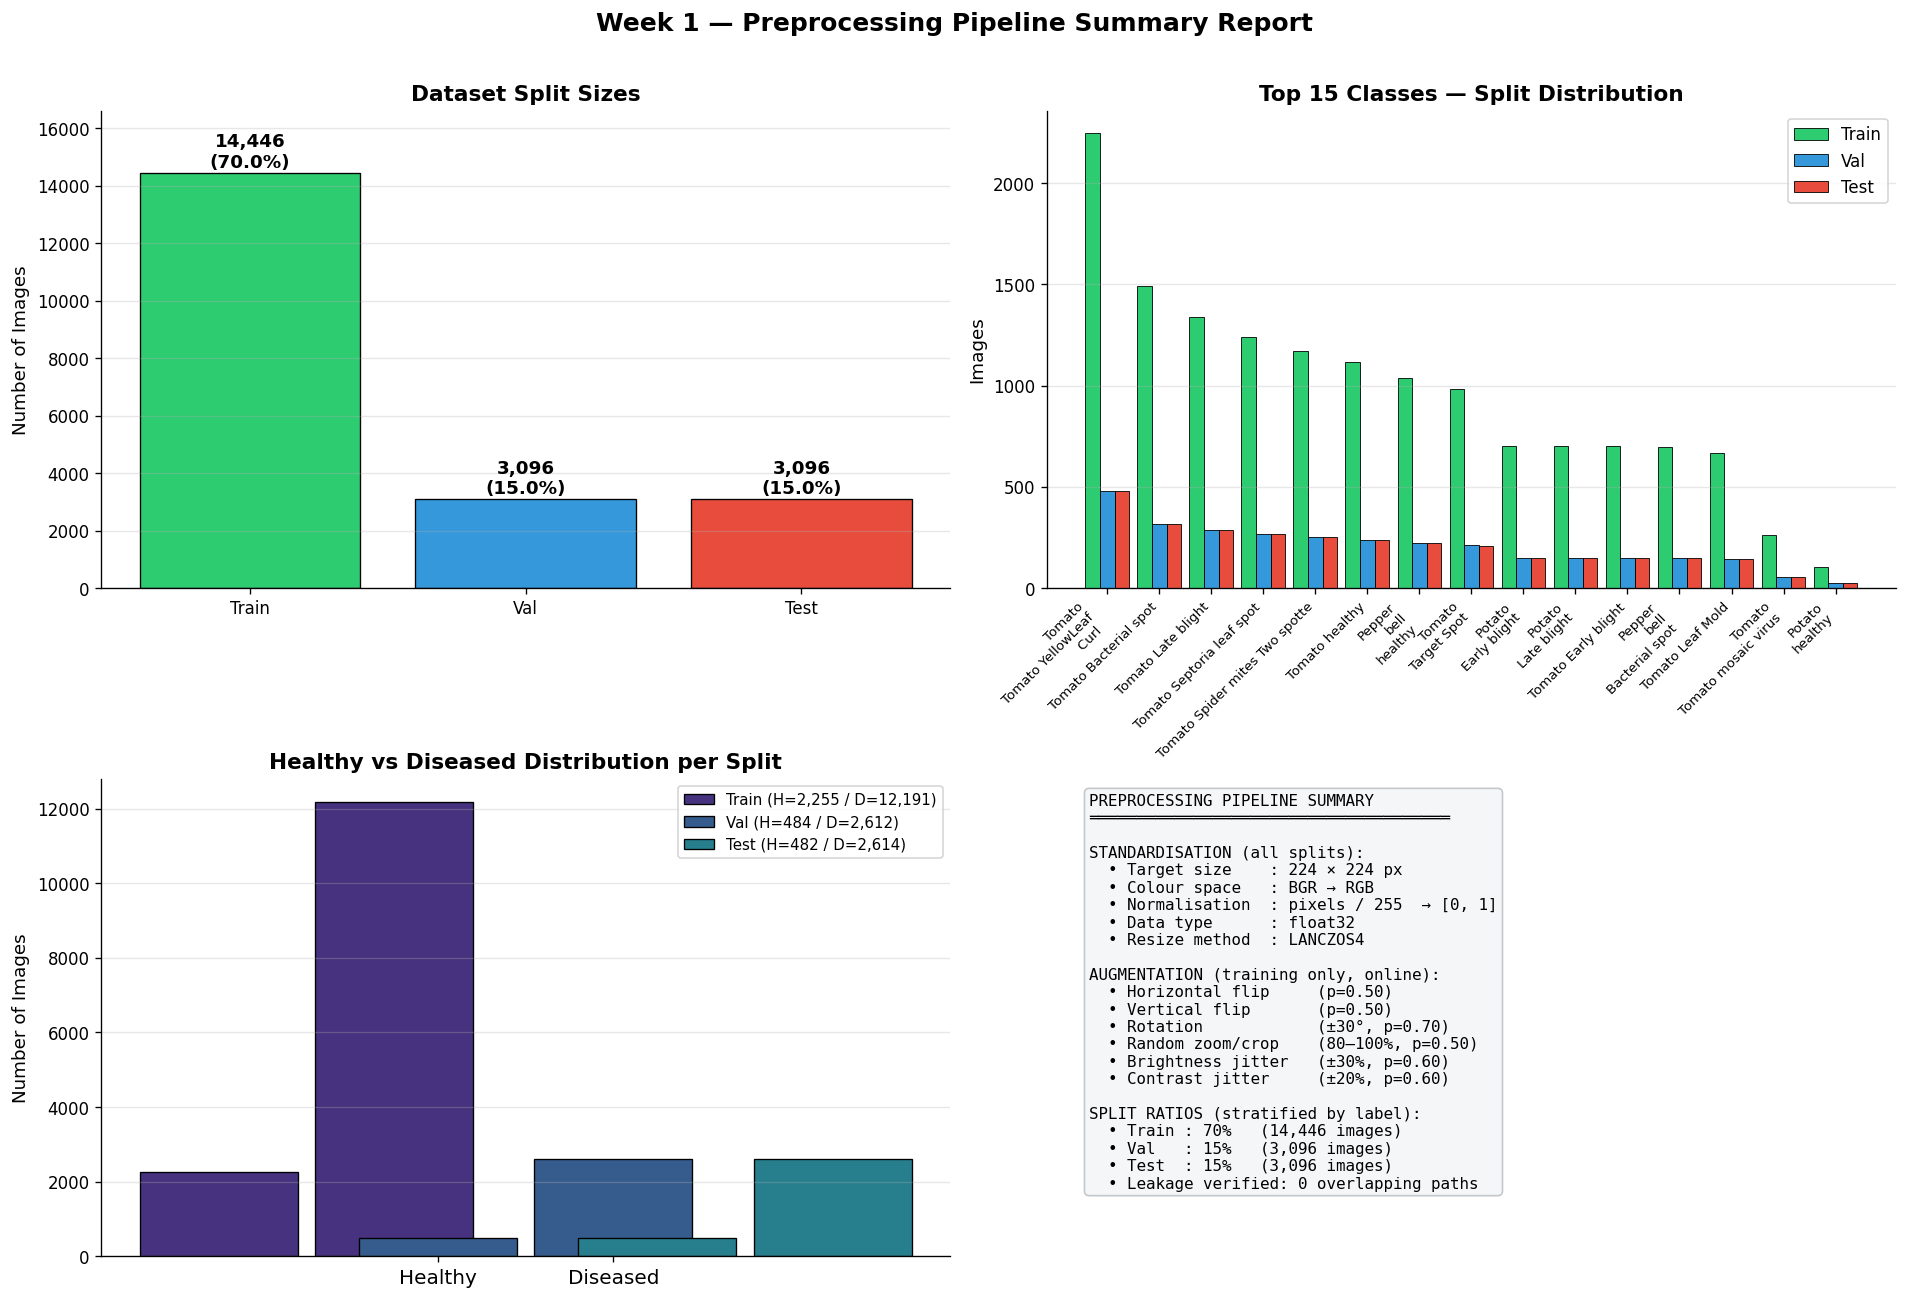

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# ── 1. Split size bar chart ────────────────────────────────────────────────────
ax = axes[0, 0]
split_sizes = {'Train': len(df_train), 'Val': len(df_val), 'Test': len(df_test)}
colors = ['#2ecc71', '#3498db', '#e74c3c']
bars = ax.bar(split_sizes.keys(), split_sizes.values(), color=colors, edgecolor='black', linewidth=0.8)
for bar, count in zip(bars, split_sizes.values()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 50,
        f'{count:,}\n({count/len(df):.1%})',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )
ax.set_title('Dataset Split Sizes', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Images', fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, max(split_sizes.values()) * 1.15)

# ── 2. Class distribution across splits (top 15 classes) ──────────────────────
ax = axes[0, 1]
top15 = df['label'].value_counts().head(15).index.tolist()

x  = np.arange(len(top15))
w  = 0.28
for i, (split_df, name, color) in enumerate([
    (df_train, 'Train', '#2ecc71'),
    (df_val,   'Val',   '#3498db'),
    (df_test,  'Test',  '#e74c3c')
]):
    counts = [split_df[split_df['label'] == lbl].shape[0] for lbl in top15]
    ax.bar(x + i * w, counts, w, label=name, color=color, edgecolor='black', linewidth=0.5)

ax.set_xticks(x + w)
ax.set_xticklabels(
    [l.replace('___', '\n').replace('__', '\n').replace('_', ' ')[:30] for l in top15],
    rotation=45, ha='right', fontsize=8
)
ax.set_ylabel('Images', fontsize=11)
ax.set_title('Top 15 Classes — Split Distribution', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

# ── 3. Healthy vs Diseased proportion ─────────────────────────────────────────
ax = axes[1, 0]
for split_df, name, offset in [
    (df_train, 'Train', -0.25),
    (df_val,   'Val',   0.0),
    (df_test,  'Test',  0.25)
]:
    healthy = (split_df['disease'] == 'healthy').sum()
    diseased = len(split_df) - healthy
    ax.bar(
        [offset - 0.1, offset + 0.1],
        [healthy, diseased],
        width=0.18,
        label=f'{name} (H={healthy:,} / D={diseased:,})',
        edgecolor='black',
        linewidth=0.8
    )

ax.set_xticks([-0.1, 0.1])
ax.set_xticklabels(['Healthy', 'Diseased'], fontsize=12)
ax.set_ylabel('Number of Images', fontsize=11)
ax.set_title('Healthy vs Diseased Distribution per Split', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

# ── 4. Augmentation pipeline summary (text panel) ─────────────────────────────
ax = axes[1, 1]
ax.axis('off')

pipeline_text = (
    "PREPROCESSING PIPELINE SUMMARY\n"
    "══════════════════════════════════════\n\n"
    "STANDARDISATION (all splits):\n"
    f"  • Target size    : {IMG_SIZE[0]} × {IMG_SIZE[1]} px\n"
    "  • Colour space   : BGR → RGB\n"
    "  • Normalisation  : pixels / 255  → [0, 1]\n"
    "  • Data type      : float32\n"
    "  • Resize method  : LANCZOS4\n\n"
    "AUGMENTATION (training only, online):\n"
    "  • Horizontal flip     (p=0.50)\n"
    "  • Vertical flip       (p=0.50)\n"
    "  • Rotation            (±30°, p=0.70)\n"
    "  • Random zoom/crop    (80–100%, p=0.50)\n"
    "  • Brightness jitter   (±30%, p=0.60)\n"
    "  • Contrast jitter     (±20%, p=0.60)\n\n"
    f"SPLIT RATIOS (stratified by label):\n"
    f"  • Train : {TRAIN_RATIO:.0%}   ({len(df_train):,} images)\n"
    f"  • Val   : {VAL_RATIO:.0%}   ({len(df_val):,} images)\n"
    f"  • Test  : {TEST_RATIO:.0%}   ({len(df_test):,} images)\n"
    f"  • Leakage verified: 0 overlapping paths"
)

ax.text(
    0.05, 0.97, pipeline_text,
    transform=ax.transAxes,
    fontsize=9.5, verticalalignment='top',
    fontfamily='monospace',
    bbox=dict(boxstyle='round', facecolor='#f4f6f8', alpha=0.9, edgecolor='#bdc3c7')
)

fig.suptitle(
    'Week 1 — Preprocessing Pipeline Summary Report',
    fontsize=15, fontweight='bold'
)
plt.tight_layout(rect=[0, 0, 1, 0.97])

summary_plot_path = REPORTS_DIR / '04b_preprocessing_summary.png'
plt.savefig(summary_plot_path, dpi=300, bbox_inches='tight')
print(f'✅ Saved: {summary_plot_path}')
plt.show()